In [1]:
import os, time
import chipwhisperer as cw

BITFILE = r'/home/sareeta/chipwhisperer/firmware/fpgas/aes/vivado/cw305_aes.runs/impl_100t/cw305_top.bit'

assert os.path.isfile(BITFILE), f"Bitstream not found: {BITFILE}"

# 1) Connect to the capture board (CWLite)
scope = cw.scope()
scope.default_setup()


# 3) Connect and Program the FPGA
print("Programming CW305 FPGA with:", BITFILE)
target = cw.target(scope, cw.targets.CW305, bsfile=BITFILE, force=True)


(ChipWhisperer NAEUSB WARNING|File naeusb.py:826) Your firmware (0.53.0) is outdated - latest is 0.54.0 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information


scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 980563                    to 11946007                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 40000007                  to 29538459                 
scope.clock.adc_rate                     changed from 40000007.0                to 29538459.0               
scope.clock.freq_ct

(ChipWhisperer Target WARNING|File CW305.py:591) Using default Verilog defines (/home/sareeta/chipwhisperer/software/chipwhisperer/hardware/firmware/cw305/cw305_aes_defines.v); if this is not what you want, provide them via the defines_files argument


In [2]:
from Crypto.Cipher import AES

# Known NIST AES-128 test vector
KEY = bytes.fromhex("2b7e151628aed2a6abf7158809cf4f3c")
PT  = bytes.fromhex("5c692f9103b2302914d7e555e4dcee49")

# Expected ciphertext
EXP_CT = AES.new(KEY, AES.MODE_ECB).encrypt(PT)
print("Expected CT:", EXP_CT.hex())


Expected CT: 06f36a65e8a99ff8907b2e5e5ddd77de


In [3]:
# Write KEY
target.fpga_write(target.REG_CRYPT_KEY, KEY)

# Write PLAINTEXT
target.fpga_write(target.REG_CRYPT_TEXTIN, PT)

# Trigger encryption
target.fpga_write(target.REG_CRYPT_GO, b"\x01")

# Small delay (AES is fast but be safe)
time.sleep(0.01)

In [4]:
# Read ciphertext
ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
print("FPGA CT   :", ct.hex())
print("MATCH?    :", ct == EXP_CT)

FPGA CT   : 06f36a65e8a99ff8907b2e5e5ddd77de
MATCH?    : True


In [5]:
for i in range(10):
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")
    time.sleep(0.002)
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
    print(i, ct.hex())

0 06f36a65e8a99ff8907b2e5e5ddd77de
1 06f36a65e8a99ff8907b2e5e5ddd77de
2 06f36a65e8a99ff8907b2e5e5ddd77de
3 06f36a65e8a99ff8907b2e5e5ddd77de
4 06f36a65e8a99ff8907b2e5e5ddd77de
5 06f36a65e8a99ff8907b2e5e5ddd77de
6 06f36a65e8a99ff8907b2e5e5ddd77de
7 06f36a65e8a99ff8907b2e5e5ddd77de
8 06f36a65e8a99ff8907b2e5e5ddd77de
9 06f36a65e8a99ff8907b2e5e5ddd77de


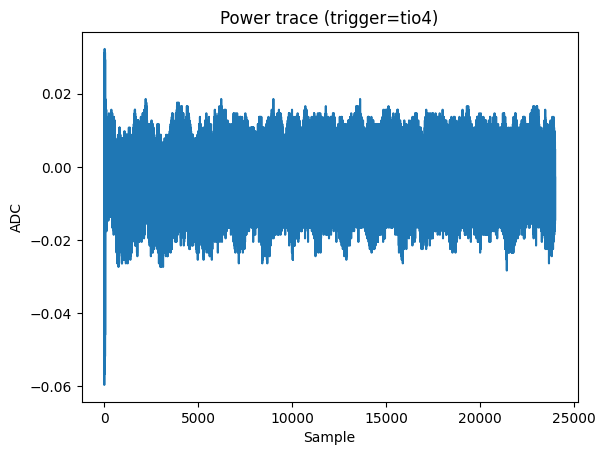

CT: 69c4e0d86a7b0430d8cdb78070b4c55a


In [6]:
import chipwhisperer as cw
import numpy as np
import time
import matplotlib.pyplot as plt

# scope = cw.scope()
# target = cw.target(scope, cw.targets.CW305)

# ---- Scope setup (adjust if you already have working settings) ----
scope.adc.samples = 24000
scope.adc.offset  = 0

# Trigger on tio4 (you said "Trigger set to tio4")
scope.trigger.triggers = "tio4"

def run_aes_once(key_bytes, pt_bytes):
    target.fpga_write(target.REG_CRYPT_KEY, key_bytes)
    target.fpga_write(target.REG_CRYPT_TEXTIN, pt_bytes)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")
    time.sleep(0.002)
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
    return ct

def capture_power_trace(key_bytes, pt_bytes):
    scope.arm()
    ct = run_aes_once(key_bytes, pt_bytes)
    ret = scope.capture()
    if ret:
        raise RuntimeError("Capture timeout")
    tr = scope.get_last_trace()
    return tr, ct

# Example single capture
key = bytes.fromhex("000102030405060708090a0b0c0d0e0f")
pt  = bytes.fromhex("00112233445566778899aabbccddeeff")

tr, ct = capture_power_trace(key, pt)

plt.figure()
plt.plot(tr)
plt.title("Power trace (trigger=tio4)")
plt.xlabel("Sample")
plt.ylabel("ADC")
plt.show()

print("CT:", ct.hex())


In [7]:
scope.default_setup()
scope.adc.samples = 24000         # number of samples per trace
scope.adc.offset  = 0
scope.adc.presamples = 200       # capture a bit before trigger
scope.adc.decimate = 1
scope.adc.timeout = 2
# ---- Gain (CWLite safe range: 20–45 dB) ----
scope.gain.db = 35
# ---- Trigger: FPGA asserts trigger at AES start ----
scope.trigger.triggers = "tio4"
#scope.trigger.module = "basic"

print(scope)

scope.adc.samples                        changed from 24000                     to 5000                     
cwlite Device
sn         = 50203220594a48303130313230313035
fw_version = 
    major = 0
    minor = 65
    debug = 0
gain = 
    mode = high
    gain = 46
    db   = 35.1484375
adc = 
    state          = False
    basic_mode     = rising_edge
    timeout        = 2
    offset         = 0
    presamples     = 200
    samples        = 24000
    decimate       = 1
    trig_count     = 4
    fifo_fill_mode = normal
clock = 
    adc_src       = clkgen_x4
    adc_phase     = 0
    adc_freq      = 29538459
    adc_rate      = 29538459.0
    adc_locked    = True
    freq_ctr      = 0
    freq_ctr_src  = extclk
    clkgen_src    = system
    extclk_freq   = 10000000
    clkgen_mul    = 2
    clkgen_div    = 26
    clkgen_freq   = 7384615.384615385
    clkgen_locked = True
trigger = 
    triggers = tio4
    module   = basic
io = 
    tio1         = serial_rx
    tio2         = serial_tx


In [8]:
scope.arm()
target.fpga_write(target.REG_CRYPT_TEXTIN, b"\x00"*16)
target.fpga_write(target.REG_CRYPT_GO, b"\x01")

if scope.capture():
    print("❌ Trigger not seen")
else:
    print("✅ Trigger OK")

✅ Trigger OK


In [9]:
#KEY = bytes.fromhex("000102030405060708090a0b0c0d0e0f")
#PT  = bytes.fromhex("00112233445566778899aabbccddeeff")
#KEY = bytes.fromhex("2b7e151628aed2a6abf7158809cf4f3c")
#PT  = bytes.fromhex("5c692f9103b2302914d7e555e4dcee49")
# Load key once
target.fpga_write(target.REG_CRYPT_KEY, KEY)

# Arm scope
scope.arm()

# Launch AES
target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
target.fpga_write(target.REG_CRYPT_GO, b"\x01")

# Capture
if scope.capture():
    raise RuntimeError("Timeout during capture")

# Read trace
trace = scope.get_last_trace()
print("Trace length:", len(trace))


Trace length: 24000


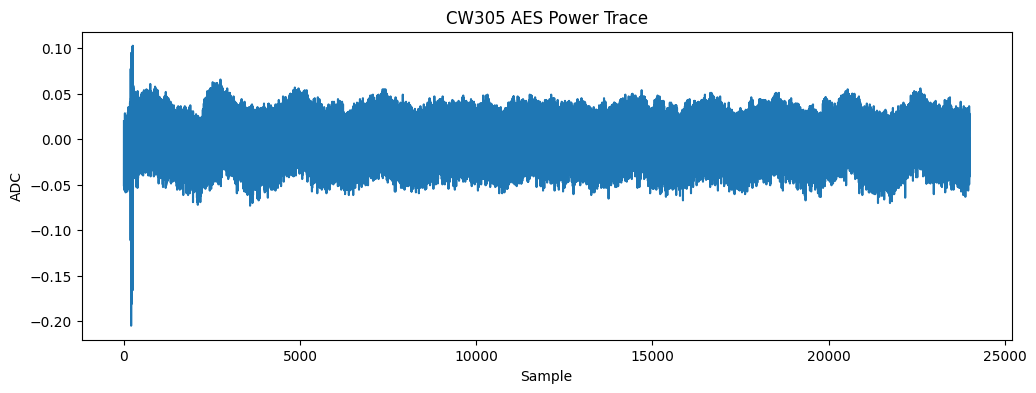

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(trace)
plt.title("CW305 AES Power Trace")
plt.xlabel("Sample")
plt.ylabel("ADC")
plt.show()

In [10]:
import numpy as np
import time
N = 10000
traces = []
pts = []
cts = []

for i in range(N):
    pt = np.random.bytes(16)

    scope.arm()
    target.fpga_write(target.REG_CRYPT_TEXTIN, pt)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

    if scope.capture():
        print("Timeout at", i)
        continue

    trace = scope.get_last_trace()
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

    traces.append(trace)
    pts.append(pt)
    cts.append(ct)

print("Captured:", len(traces), "traces")


Captured: 10000 traces


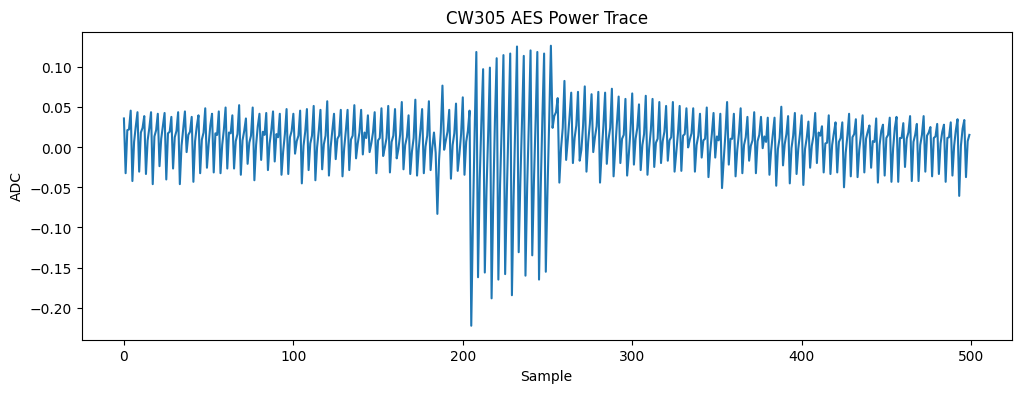

In [11]:
plt.figure(figsize=(12,4))
plt.plot(trace)
plt.title("CW305 AES Power Trace")
plt.xlabel("Sample")
plt.ylabel("ADC")
plt.show()

In [12]:
import numpy as np

# Convert lists to numpy arrays for efficient storage
traces_array = np.array(traces, dtype=np.float32)
pts_array = np.array([list(p) for p in pts], dtype=np.uint8)
cts_array = np.array([list(c) for c in cts], dtype=np.uint8)

# Save to a single compressed file
file_name = "normal_aes_capture_10k_2nd.npz"
np.savez_compressed(file_name, 
                    traces=traces_array, 
                    pts=pts_array, 
                    cts=cts_array)

print(f"Successfully saved {len(traces)} traces to {file_name}")

Successfully saved 10000 traces to normal_aes_capture_10k_2nd.npz


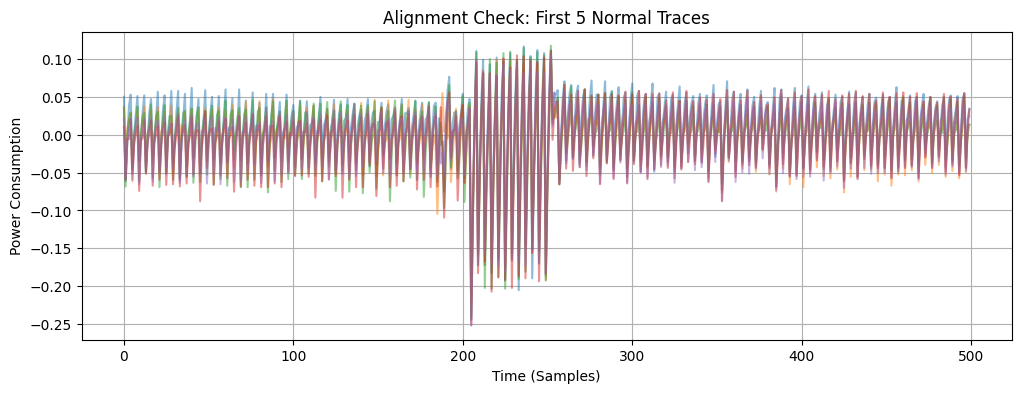

In [13]:
import matplotlib.pyplot as plt

def check_alignment(traces, num_samples=5):
    plt.figure(figsize=(12, 4))
    for i in range(num_samples):
        plt.plot(traces[i], alpha=0.5)
    
    plt.title(f"Alignment Check: First {num_samples} Normal Traces")
    plt.xlabel("Time (Samples)")
    plt.ylabel("Power Consumption")
    plt.grid(True)
    plt.show()

check_alignment(traces_array)

In [11]:
import chipwhisperer as cw
import numpy as np
import time

# Use your existing scope/target if already connected
# scope = cw.scope()
# target = cw.target(scope, cw.targets.CW305)

# fixed vectors (good for glitch scanning)
#KEY = bytes.fromhex("000102030405060708090a0b0c0d0e0f")
#PT  = bytes.fromhex("00112233445566778899aabbccddeeff")

KEY = bytes.fromhex("2b7e151628aed2a6abf7158809cf4f3c")
PT  = bytes.fromhex("5c692f9103b2302914d7e555e4dcee49")

target.fpga_write(target.REG_CRYPT_KEY, KEY)

# expected ciphertext
from Crypto.Cipher import AES
EXP_CT = AES.new(KEY, AES.MODE_ECB).encrypt(PT)
print("Expected:", EXP_CT.hex())


Expected: 06f36a65e8a99ff8907b2e5e5ddd77de


In [12]:
# scope.gain.gain = 46
# scope.gain.mode = "high"
# scope.adc.samples = 500
# scope.adc.offset = 0
# scope.adc.basic_mode = "rising_edge"
# scope.clock.adc_src = "clkgen_x4"
scope.clock.freq_ctr_src = "clkgen"
scope.clock.adc_phase = 0
scope.trigger.triggers = "tio4"

In [13]:
scope.clock.extclk_freq = 10000000
scope.clock.clkgen_mul = 5
scope.clock.clkgen_div = 48
scope.clock.clkgen_freq = 10000000

In [12]:
scope.io.glitch_lp = True
scope.io.glitch_hp = False

In [13]:
scope.io.hs2 = "glitch"
scope.glitch.clk_src = 'clkgen'
scope.glitch.ext_offset = 0

In [18]:
#scope.glitch.trigger_src ="ext_single" #"continuous" #change this depending on glitching desired   "ext_single"  "continuous"
#scope.glitch.output = "clock_xor"
#scope.glitch.output = "clock_xor"
scope.glitch.output = "glitch_only"


In [19]:
scope.glitch.width = 10
scope.glitch.offset = -20
#self.api.setParameter(['Glitch Module', 'Output Mode', 'Clock XORd'])
scope.glitch.repeat = 5   
print("Glitch ready.")

Glitch ready.


In [20]:
def aes_encrypt_once():
    # fire AES
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")
    # small wait so ciphertext register updates even if trigger missed
    time.sleep(0.001)
    return bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

def glitch_and_read():
    # arm scope + glitch
    scope.arm()

    # launch AES (this generates the external trigger used by ext_single)
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

    # capture waveform (optional but useful for debugging alignment)
    cap_timeout = scope.capture()
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

    if cap_timeout:
        return "no_trigger", ct, None

    tr = scope.get_last_trace()

    if ct == EXP_CT:
        return "correct", ct, tr
    else:
        return "faulty", ct, tr


In [ ]:
for i in range(10):
    label, ct, tr = glitch_and_read()
    print(i, label, ct.hex())

(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08


0 no_trigger 06f36a65e8a99ff8907b2e5e5ddd77de


In [ ]:
import numpy as np

# Configuration
N_PER_SETTING = 5
records = []
traces = []
labels = []
faults = []
hits = {"correct": 0, "faulty": 0, "no_trigger": 0}

# Range Setup
widths  = range(-49, 49, 2)
offsets = range(-49, 49, 2)

print("Starting Glitch Loop...")

for w in widths:
    scope.glitch.width = w
    for off in offsets:
        scope.glitch.offset = off
        
        for rep in range(N_PER_SETTING):
            # --- THE WORKING LOGIC FROM CODE 1 ---
            scope.arm()
            
            # Launch AES
            target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
            target.fpga_write(target.REG_CRYPT_GO, b"\x01")
            
            # Capture the hardware result
            cap_timeout = scope.capture()
            ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
            
            # Trace processing (from Code 2)
            tr = None
            if not cap_timeout:
                tr = np.array(scope.get_last_trace(), dtype=np.float32)
            # --------------------------------------

            # Labeling Logic
            if cap_timeout:
                label = "no_trigger"
            elif ct == EXP_CT:
                label = "correct"
            else:
                label = "faulty"
                faults.append((w, off, ct.hex()))
                print(f"FAULT! w={w} off={off} ct={ct.hex()}")

            # Store in Hits dictionary
            hits[label] += 1

            # Create the record (from Code 2)
            records.append({
                "width": w,
                "offset": off,
                "rep": rep,
                "label": label,
                "ct_hex": ct.hex(),
            })

            # Store trace if it exists
            if tr is not None:
                traces.append(tr)
                labels.append(label)

print("\n--- Scan Complete ---")
print("Summary:", hits)
print("Total records:", len(records))

Starting Glitch Loop...


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no t

In [27]:
import numpy as np
import json

traces_np = np.vstack(traces) 

In [23]:
import numpy as np
import json

traces_np = np.vstack(traces)  # (num_captured, samples)

np.savez(
    "cw305_glitch_traces_2nd.npz",
    traces=traces_np,
    labels=np.array(labels, dtype="U10"),
    records_json=np.array([json.dumps(r) for r in records], dtype=object),
)

print("Saved: cw305_glitch_traces2nd.npz")


Saved: cw305_glitch_traces2nd.npz


In [24]:
import json
import numpy as np

# Save the numerical traces and labels
np.savez_compressed("glitch_results_traces_2nd.npz", traces=np.array(traces), labels=np.array(labels))

# Save the metadata (records) as a JSON file
with open("glitch_metadata_2nd.json", "w") as f:
    json.dump(records, f, indent=4)

print("Files saved: glitch_results_traces_2nd.npz and glitch_metadata_2nd.json")

Files saved: glitch_results_traces_2nd.npz and glitch_metadata_2nd.json


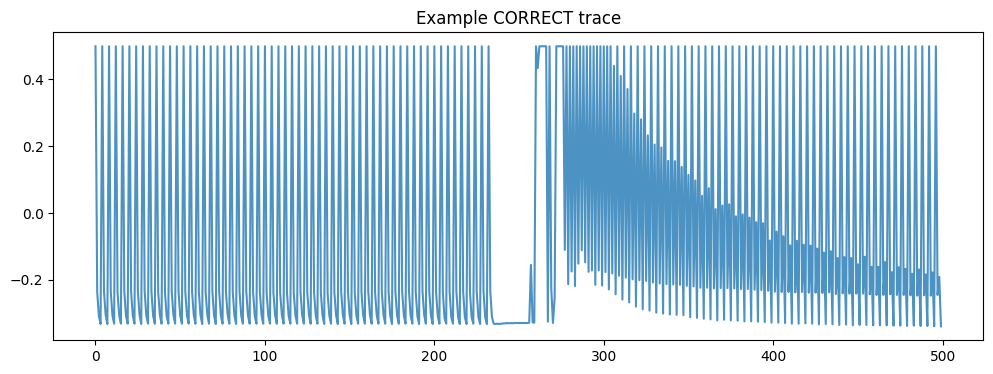

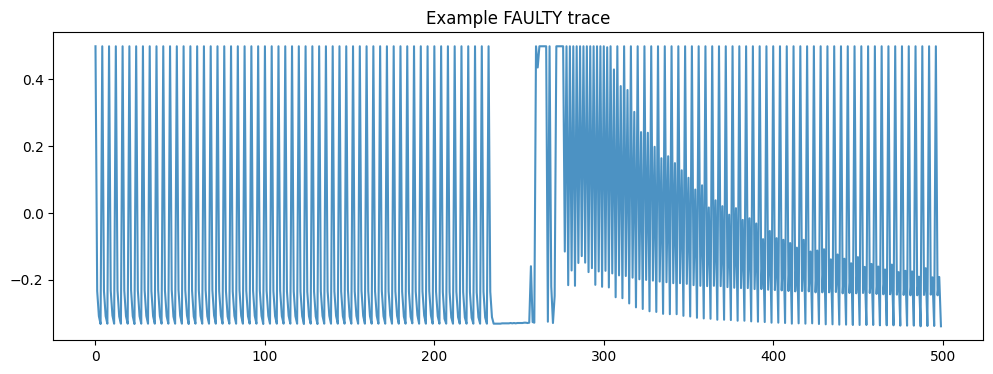

In [28]:
import matplotlib.pyplot as plt
import numpy as np

tr = traces_np
lab = np.array(labels)

fault_idx = np.where(lab == "faulty")[0]
corr_idx  = np.where(lab == "correct")[0]

plt.figure(figsize=(12,4))
if len(corr_idx) > 0:
    plt.plot(tr[corr_idx[0]], alpha=0.8)
    plt.title("Example CORRECT trace")
    plt.show()

plt.figure(figsize=(12,4))
if len(fault_idx) > 0:
    plt.plot(tr[fault_idx[0]], alpha=0.8)
    plt.title("Example FAULTY trace")
    plt.show()


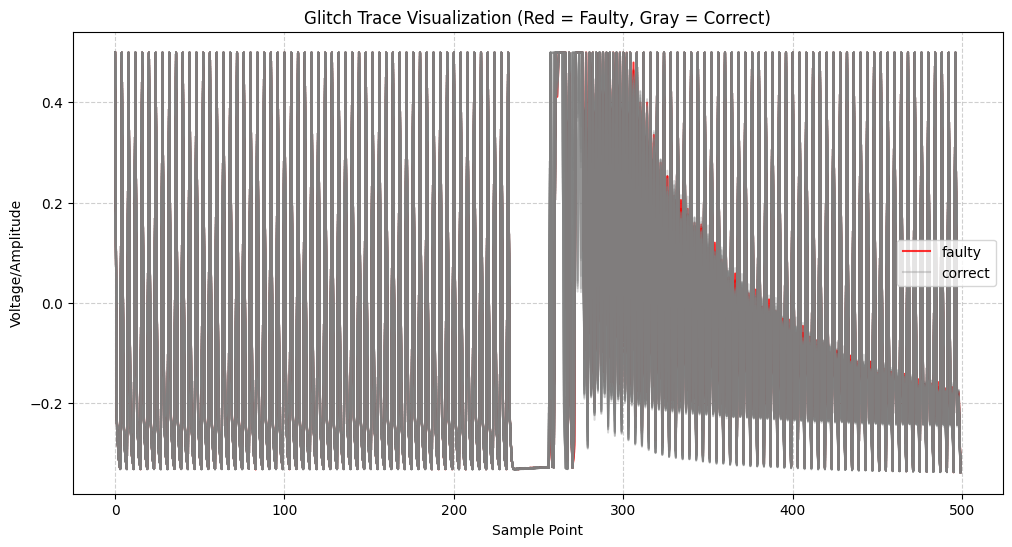

In [26]:
import matplotlib.pyplot as plt

def plot_glitch_traces(traces, labels, num_to_plot=50):
    plt.figure(figsize=(12, 6))
    
    # Track if we've added to legend to avoid duplicate labels
    added_labels = set()
    
    # Plot a subset to keep the graph readable
    for i in range(min(len(traces), num_to_plot)):
        label = labels[i]
        color = 'gray' # Default for correct
        alpha = 0.3
        
        if label == "faulty":
            color = 'red'
            alpha = 0.8
        elif label == "no_trigger":
            color = 'orange'
            alpha = 0.5
            
        line_label = label if label not in added_labels else None
        plt.plot(traces[i], color=color, alpha=alpha, label=line_label)
        if line_label:
            added_labels.add(line_label)

    plt.title("Glitch Trace Visualization (Red = Faulty, Gray = Correct)")
    plt.xlabel("Sample Point")
    plt.ylabel("Voltage/Amplitude")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Call the function
plot_glitch_traces(traces, labels)

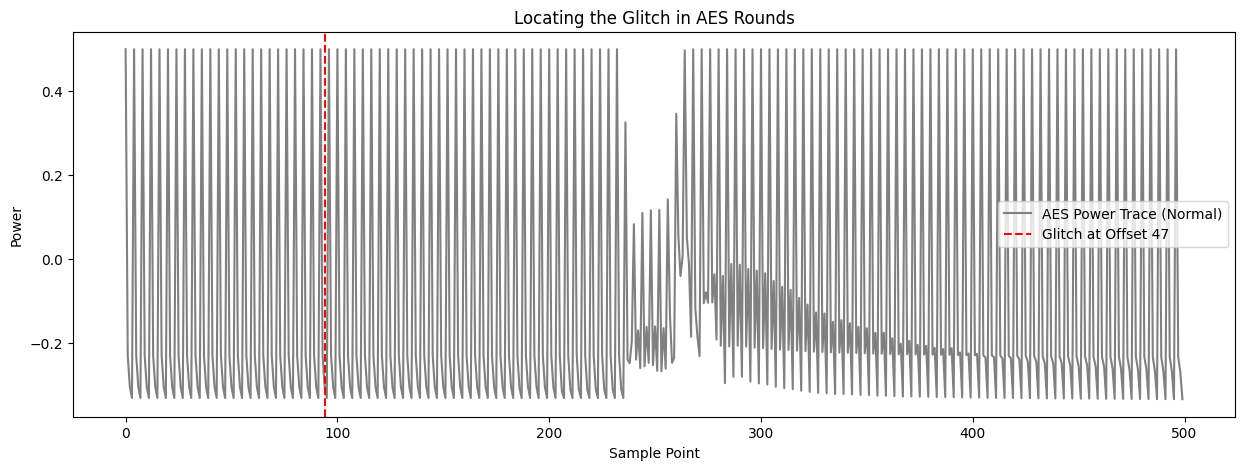

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Take a 'Normal Trace' to use as a reference
ref_trace = np.mean(traces, axis=0) # Average trace for clarity

# 2. Pick a specific glitch offset you want to inspect
# offset_samples = (scope.glitch.offset) + (any hardware delay)
# Note: On many CW hardwares, the 'offset' is in clock cycles. 
# If your scope captures at 4x the clock rate, 1 cycle = 4 samples.
OFFSET_TO_SAMPLES = 2  # Change this based on your scope.clock.adc_src

target_offset = 47# Example offset that caused a fault
glitch_pos = target_offset * OFFSET_TO_SAMPLES

plt.figure(figsize=(15, 5))
plt.plot(ref_trace, color='gray', label='AES Power Trace (Normal)')
plt.axvline(x=glitch_pos, color='red', linestyle='--', label=f'Glitch at Offset {target_offset}')

plt.title("Locating the Glitch in AES Rounds")
plt.xlabel("Sample Point")
plt.ylabel("Power")
plt.legend()
plt.show()

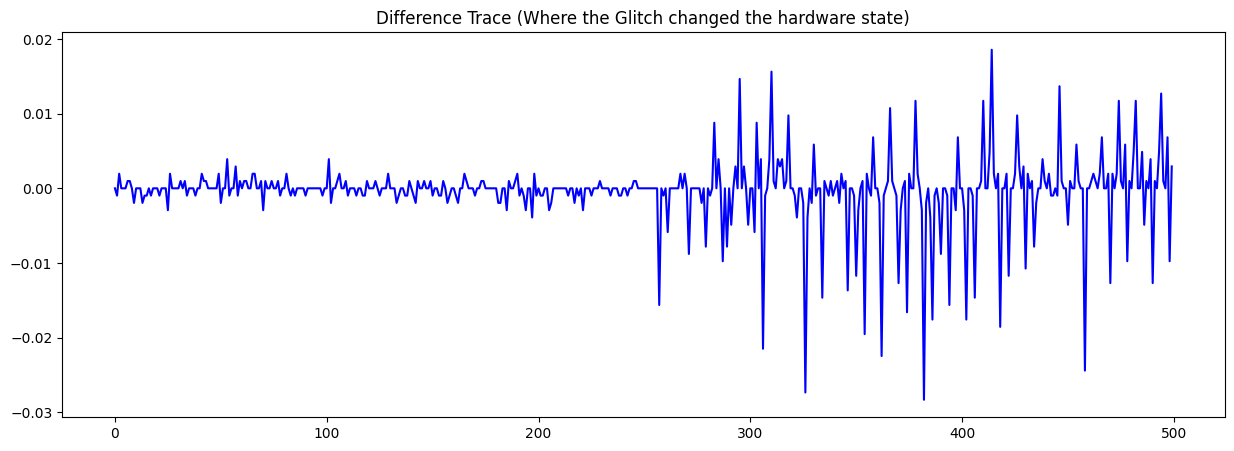

In [28]:
# Assuming you have one faulty trace and one correct trace from your previous lists
faulty_idx = labels.index('faulty')
correct_idx = labels.index('correct')

diff = traces[faulty_idx] - traces[correct_idx]

plt.figure(figsize=(15, 5))
plt.plot(diff, color='blue')
plt.title("Difference Trace (Where the Glitch changed the hardware state)")
plt.show()

In [29]:
def xor_bytes(a,b): 
    return bytes(x^y for x,y in zip(a,b))

def bitcount_bytes(x):
    return sum(b.bit_count() for b in x)

def summarize_fault(ct_faulty: bytes, ct_correct: bytes):
    d = xor_bytes(ct_faulty, ct_correct)
    bitflips = bitcount_bytes(d)
    byte_flips = sum(1 for b in d if b != 0)
    flipped_positions = [i for i,b in enumerate(d) if b != 0]
    return bitflips, byte_flips, flipped_positions, d

# Example usage for a list of faulty ciphertexts:
# fault_cts_bytes = [bytes.fromhex(r["ct_hex"]) for r in records if r["label"]=="faulty"]
for r in [rr for rr in records if rr["label"]=="faulty"][:10]:
    ct_f = bytes.fromhex(r["ct_hex"])
    bitflips, byteflips, pos, d = summarize_fault(ct_f, EXP_CT)
    print("w/off", r["width"], r["offset"], "bitflips", bitflips, "byteflips", byteflips, "bytes", pos, "ΔC", d.hex())


w/off -49 -49 bitflips 62 byteflips 16 bytes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] ΔC 25952afe0152cad3b89b46f7ccd20c1a
w/off -49 -49 bitflips 6 byteflips 3 bytes [3, 7, 11] ΔC 00000040000000210000000b00000000
w/off -49 -49 bitflips 62 byteflips 16 bytes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] ΔC 6ea22c45a02bb26bf8ac5c1ab7b29d50
w/off -29 31 bitflips 18 byteflips 8 bytes [3, 5, 8, 10, 11, 12, 13, 14] ΔC 0000009200080000880008512008be00
w/off -27 29 bitflips 24 byteflips 14 bytes [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 14, 15] ΔC 02406a60808090300002080610005052
w/off -17 19 bitflips 9 byteflips 2 bytes [11, 14] ΔC 0000000000000000000000510000be00
w/off -13 15 bitflips 18 byteflips 8 bytes [3, 5, 8, 10, 11, 12, 13, 14] ΔC 0000009200080000880008512008be00
w/off -11 13 bitflips 13 byteflips 5 bytes [5, 8, 10, 11, 14] ΔC 0000000000080000880008510000be00
w/off -11 13 bitflips 43 byteflips 16 bytes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] ΔC 02606

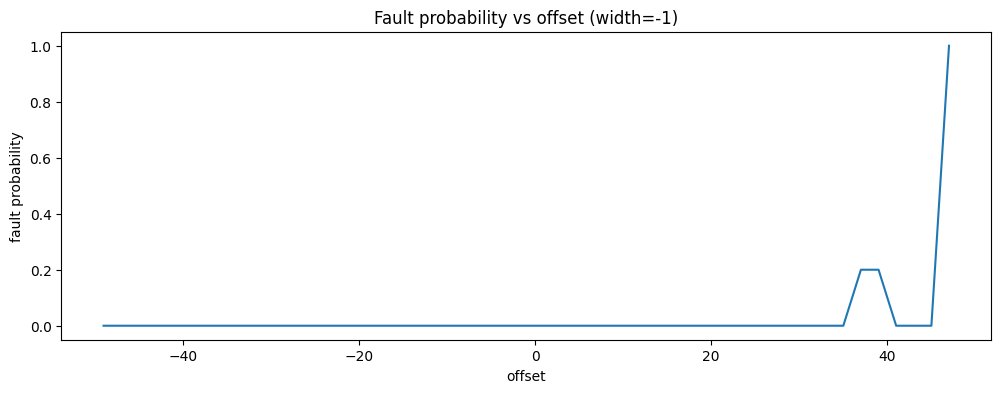

In [30]:
import numpy as np

# records should include width, offset, label
# Filter to a fixed width if you swept that way
W = -1  # set your chosen width
sub = [r for r in records if r["width"] == W]

offsets = sorted(set(r["offset"] for r in sub))
fault_rate = []
for off in offsets:
    rs = [r for r in sub if r["offset"] == off]
    if not rs: 
        continue
    fault_rate.append((off, sum(r["label"]=="faulty" for r in rs)/len(rs)))

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot([x for x,_ in fault_rate], [y for _,y in fault_rate])
plt.title(f"Fault probability vs offset (width={W})")
plt.xlabel("offset")
plt.ylabel("fault probability")
plt.show()


In [33]:
import numpy as np
import time

scope.trigger.triggers = "tio4"
scope.glitch.trigger_src = "ext_single"

W = -1      # use your known fault width
R = 10          # repeat you used to get faults

offsets = list(range(-200, 201, 2))
trials_per_offset = 20

def run_glitch(off):
    label, trace, ct = glitch_trace_once(width=W, offset=off, repeat=R)
    return label, trace, ct

records = []
for off in offsets:
    for t in range(trials_per_offset):
        label, trace, ct = run_glitch(off)
        records.append({"off": off, "label": label, "ct": ct, "trace": trace})

print("Total attempts:", len(records))
print("Faults:", sum(r["label"]=="faulty" for r in records))


NameError: name 'glitch_trace_once' is not defined

(ChipWhisperer Other ERROR|File util.py:419) Setting unknown attribute trigsrc in <class 'chipwhisperer.capture.scopes.cwhardware.ChipWhispererExtra.TriggerSettings'>


Trigger object: triggers = tio4
module   = basic

✅ Trigger seen on tio1
✅ Trigger seen on tio2
✅ Trigger seen on tio3
✅ Trigger seen on tio4


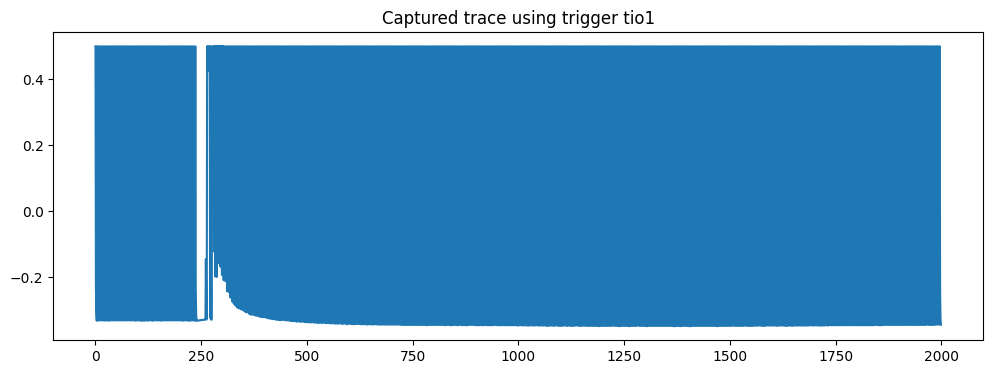

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import time

pins = ["tio1", "tio2", "tio3", "tio4"]

scope.adc.samples = 2000
scope.adc.presamples = 200
scope.gain.db = 35

# On your version, module is read-only, so DO NOT set scope.trigger.module
print("Trigger object:", scope.trigger)

found = []

for pin in pins:
    try:
        # Some CW versions use trigsrc
        scope.trigger.trigsrc = pin

        scope.arm()
        target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
        target.fpga_write(target.REG_CRYPT_GO, b"\x00")
        target.fpga_write(target.REG_CRYPT_GO, b"\x01")

        if not scope.capture():
            tr = np.array(scope.get_last_trace(), dtype=np.float32)
            found.append((pin, tr))
            print("✅ Trigger seen on", pin)
        else:
            print("❌ No trigger on", pin)

    except Exception as e:
        print("Error on", pin, ":", repr(e))

if found:
    pin, tr = found[0]
    plt.figure(figsize=(12,4))
    plt.plot(tr)
    plt.title(f"Captured trace using trigger {pin}")
    plt.show()
else:
    print("No TIO pin triggered. It may not be routed to the CW trigger input pin.")


In [10]:
print("Trigger attributes:", [a for a in dir(scope.trigger) if not a.startswith("_")])
print("IO attributes:", [a for a in dir(scope.io) if "tio" in a.lower() or "trig" in a.lower()])


Trigger attributes: ['add_read_only', 'cwe', 'disable_newattr', 'disable_strict_newattr', 'enable_newattr', 'getTriggers', 'last_module', 'module', 'remove_read_only', 'setTriggers', 'supported_tpins', 'triggers', 'trigsrc']
IO attributes: ['GPIO_PIN_TIO1', 'GPIO_PIN_TIO2', 'GPIO_PIN_TIO3', 'GPIO_PIN_TIO4', 'TIO_MODE_TRANSLATE', '__annotations__', '_get_tio_mode', '_get_tio_str', '_is_valid_tio_mode', '_read_tio_pin', '_set_tio_mode', 'glitch_trig_mcx', 'read_tio_states', 'tio1', 'tio1_mode', 'tio1_state', 'tio2', 'tio2_mode', 'tio2_state', 'tio3', 'tio3_mode', 'tio3_state', 'tio4', 'tio4_mode', 'tio4_state', 'tio_state_mask', 'tio_states']


In [11]:
import time

def run_aes():
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x00")
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

# pick one pin to observe (start with tio1)
PIN_STATE_ATTR = "tio1_state"  # try tio1_state / tio2_state / ...

states = []
t_start = time.time()

run_aes()
# sample for a short window
for _ in range(2000):
    states.append(getattr(scope.io, PIN_STATE_ATTR))
# no sleep: sample as fast as python can

# Count transitions
transitions = sum(1 for i in range(1, len(states)) if states[i] != states[i-1])

print("Samples:", len(states))
print("Transitions detected:", transitions)
print("First 50 states:", states[:50])


Samples: 2000
Transitions detected: 0
First 50 states: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [13]:
scope.adc.samples = 2000
scope.adc.presamples = 200
scope.gain.db = 35
scope.trigger.triggers = "tio4"   # or tio4
delays = [0.0, 0.00005, 0.0001, 0.0002]  # seconds (50us,100us,200us)
captured = []

for d in delays:
    # start AES first
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x00")
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

    time.sleep(d)

    # now arm and try to catch the next pulse
    scope.arm()
    if scope.capture():
        print("No trigger at delay", d)
        continue

    tr = np.array(scope.get_last_trace(), dtype=np.float32)
    captured.append((d, tr))
    print("Captured at delay", d)

# plot a few
if captured:
    plt.figure(figsize=(12,4))
    for d, tr in captured:
        plt.plot(tr, alpha=0.4, label=f"{d*1e6:.0f}us")
    plt.title("Captures triggered on round pulse with different arming delays")
    plt.legend()
    plt.show()

(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a


No trigger at delay 0.0


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a


No trigger at delay 5e-05


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a


No trigger at delay 0.0001


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a


No trigger at delay 0.0002


In [14]:
import numpy as np
import time

scope.adc.samples = 2000
scope.adc.presamples = 200
scope.gain.db = 35

# use triggers property (your version)
scope.trigger.triggers = "tio4"   # pick ONE, start with tio4

def run_aes():
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x00")
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

# Try many times
ok = 0
for i in range(30):
    scope.arm()
    run_aes()
    if not scope.capture():
        ok += 1

print("Triggers caught:", ok, "/ 30")


Triggers caught: 30 / 30


In [15]:
for pin in ["tio1", "tio2", "tio3", "tio4"]:
    scope.trigger.triggers = pin
    ok = 0
    for i in range(20):
        scope.arm()
        run_aes()
        if not scope.capture():
            ok += 1
    print(pin, "caught", ok, "/ 20")


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no t

tio1 caught 0 / 20


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0f
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0e
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0f
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0e
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0f
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0e
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no t

tio2 caught 0 / 20


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no t

tio3 caught 0 / 20
tio4 caught 20 / 20


In [16]:
[a for a in dir(target) if "ROUND" in a.upper()]


[]

In [40]:
# Example: replace with your address or constant
REG_ROUND = target.REG_ROUND_COUNT  # or e.g. 0x2C

val = int.from_bytes(target.fpga_read(REG_ROUND, 1), "little")
print("Round reg (idle):", val)


AttributeError: 'CW305' object has no attribute 'REG_ROUND_COUNT'

In [41]:
import time

def read_round():
    return int.from_bytes(target.fpga_read(REG_ROUND, 1), "little")

# trigger AES
target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
target.fpga_write(target.REG_CRYPT_GO, b"\x00")
target.fpga_write(target.REG_CRYPT_GO, b"\x01")

# poll quickly
samples = []
t0 = time.time()
for _ in range(200):
    samples.append(read_round())
# optional tiny sleep if you want longer window:
# time.sleep(0.0001)

print("Unique round values seen:", sorted(set(samples)))
print("First 30:", samples[:30])


NameError: name 'REG_ROUND' is not defined

In [42]:
import numpy as np
import time

def collect_fault_traces(width, offset, K=200, max_attempts=20000, sleep_s=0.0):
    fault_traces = []
    fault_cts = []
    meta = []  # list of dicts

    attempts = 0
    while len(fault_traces) < K and attempts < max_attempts:
        attempts += 1
        label, trace, ct = glitch_capture_one(width, offset)

        if label == "faulty" and trace is not None:
            fault_traces.append(trace)
            fault_cts.append(ct)
            meta.append({"attempt": attempts, "width": width, "offset": offset, "ct_hex": ct.hex()})

            if len(fault_traces) % 10 == 0:
                print(f"Collected faults: {len(fault_traces)}/{K} (attempts={attempts})")

        if sleep_s > 0:
            time.sleep(sleep_s)

    fault_traces = np.vstack(fault_traces) if len(fault_traces) else np.empty((0, scope.adc.samples), dtype=np.float32)
    fault_cts = np.array([c.hex() for c in fault_cts], dtype=object)

    print("Done. Faults collected:", fault_traces.shape[0], "Attempts:", attempts)
    return fault_traces, fault_cts, meta

# ---- choose your best setting from (2) ----
BEST_W = 1   # change
BEST_O = -47  # change

fault_traces, fault_cts, meta = collect_fault_traces(BEST_W, BEST_O, K=100, max_attempts=5000)

# save
import json
np.savez(
    "cw305_fault_only_traces.npz",
    traces=fault_traces,
    cts=fault_cts,
    meta_json=np.array([json.dumps(m) for m in meta], dtype=object),
)
print("Saved: cw305_fault_only_traces.npz")


NameError: name 'glitch_capture_one' is not defined

In [43]:
faults = []   # store (width, offset, ciphertext_hex)
hits = {"correct":0, "faulty":0, "no_trigger":0}

widths  = range(-49, 49,2 )       # adjust range later
offsets = range(-49, 49,2)     # adjust range later

for w in widths:
    scope.glitch.width = w
    for off in offsets:
        scope.glitch.offset = off

        label, ct, tr = glitch_and_read()
        hits[label] += 1

        if label == "faulty":
            faults.append((w, off, ct.hex()))
            print("FAULT OCCURED HERE.. OHHH NOOOOOOOO", "w=", w, "off=", off, "ct=", ct.hex())
        # else:
        #     print("NORMAL", "w=", w, "off=", off, "ct=", ct.hex())

print("Summary:", hits)
print("Fault count:", len(faults))


FAULT OCCURED HERE.. OHHH NOOOOOOOO w= -1 off= 47 ct= 06f36a65e8a99ff8167b2e5e5ddd77de
FAULT OCCURED HERE.. OHHH NOOOOOOOO w= 17 off= -15 ct= 06f36a65e8a99ff8907b260f5dddc9de
Summary: {'correct': 2399, 'faulty': 2, 'no_trigger': 0}
Fault count: 2


In [34]:
import numpy as np
import time

#PT = bytes.fromhex("00112233445566778899aabbccddeeff")

def launch_aes(pt):
    target.fpga_write(target.REG_CRYPT_TEXTIN, pt)
    target.fpga_write(target.REG_CRYPT_GO, b"\x00")
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

def glitch_capture_one(width, offset):
    # set glitch params
    scope.glitch.width = width
    scope.glitch.offset = offset

    # arm capture
    scope.arm()

    # run AES (this also triggers the glitch via ext_single)
    launch_aes(PT)

    # capture waveform
    timed_out = scope.capture()
    trace = None if timed_out else np.array(scope.get_last_trace(), dtype=np.float32)

    # read ciphertext regardless (sometimes still updates)
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

    if timed_out:
        label = "no_trigger"
    elif ct == EXP_CT:
        label = "correct"
    else:
        label = "faulty"

    return label, trace, ct

In [35]:
scope.adc.samples = 3000
scope.adc.presamples = 200
scope.gain.db = 35
scope.adc.timeout = 2

In [36]:

CENTER_W = -1
CENTER_O = 47

#w_list = range(CENTER_W -4, CENTER_W + 4, 1)
#o_list = range(CENTER_O -4, CENTER_O + 2, 1)
w_list = range(CENTER_W - 2, CENTER_W, 1) # Look slightly around the spot
o_list = range(CENTER_O - 5, CENTER_O + 2, 2)


N_PER_SETTING = 10

In [37]:
records = []  # list of dicts
traces = []
labels = []

for w in w_list:
    for o in o_list:
        for rep in range(N_PER_SETTING):
            label, trace, ct = glitch_capture_one(w, o)

            records.append({
                "width": w,
                "offset": o,
                "rep": rep,
                "label": label,
                "ct_hex": ct.hex(),
            })

            # store traces only if we actually captured a trace
            if trace is not None:
                traces.append(trace)
                labels.append(label)

            if label == "faulty":
                print("FAULT", "w", w, "off", o, "ct", ct.hex())

print("Total attempts:", len(records))
print("Captured traces:", len(traces))
print("Faults:", sum(r["label"]=="faulty" for r in records))


Total attempts: 80
Captured traces: 80
Faults: 0


In [38]:
faults = []   # store (width, offset, ciphertext_hex)
hits = {"correct":0, "faulty":0, "no_trigger":0}

widths  = range(-49, 49,2 )       # adjust range later
offsets = range(-49, 49,2)     # adjust range later

for w in widths:
    scope.glitch.width = w
    for off in offsets:
        scope.glitch.offset = off

        label, ct, tr = glitch_and_read()
        hits[label] += 1

        if label == "faulty":
            faults.append((w, off, ct.hex()))
            print("FAULT OCCURED HERE.. OHHH NOOOOOOOO", "w=", w, "off=", off, "ct=", ct.hex())
        # else:
        #     print("NORMAL", "w=", w, "off=", off, "ct=", ct.hex())

print("Summary:", hits)
print("Fault count:", len(faults))


FAULT OCCURED HERE.. OHHH NOOOOOOOO w= -1 off= 47 ct= 06f36a65e8a99ff8167b2e5e5ddd77de
FAULT OCCURED HERE.. OHHH NOOOOOOOO w= 35 off= -33 ct= 00020001000907080020240008050180
Summary: {'correct': 2399, 'faulty': 2, 'no_trigger': 0}
Fault count: 2


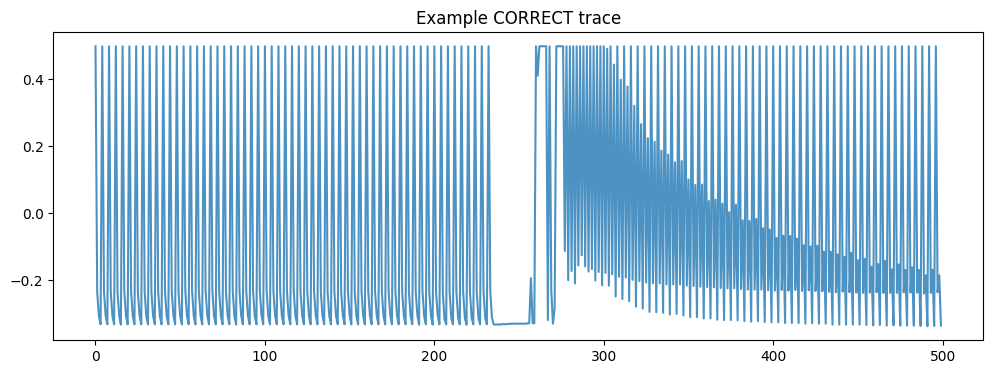

<Figure size 1200x400 with 0 Axes>

In [39]:
import matplotlib.pyplot as plt
import numpy as np

tr = traces_np
lab = np.array(labels)

fault_idx = np.where(lab == "faulty")[0]
corr_idx  = np.where(lab == "correct")[0]

plt.figure(figsize=(12,4))
if len(corr_idx) > 0:
    plt.plot(tr[corr_idx[0]], alpha=0.8)
    plt.title("Example CORRECT trace")
    plt.show()

plt.figure(figsize=(12,4))
if len(fault_idx) > 0:
    plt.plot(tr[fault_idx[0]], alpha=0.8)
    plt.title("Example FAULTY trace")
    plt.show()


In [24]:
print(scope.clock)

adc_src       = clkgen_x1
adc_phase     = 0
adc_freq      = 7384620
adc_rate      = 7384620.0
adc_locked    = True
freq_ctr      = 10000396
freq_ctr_src  = extclk
clkgen_src    = system
extclk_freq   = 10000000
clkgen_mul    = 2
clkgen_div    = 26
clkgen_freq   = 7384615.384615385
clkgen_locked = True



In [29]:
print([x for x in dir(scope.glitch) if "output" in x or "clk" in x or "repeat" in x])
print("glitch output =", scope.glitch.output)


['_output_modes', 'clk_src', 'output', 'repeat']
glitch output = clock_xor


In [41]:
import time
import numpy as np

#PT = bytes.fromhex("00112233445566778899aabbccddeeff")

def launch_aes(pt):
    target.fpga_write(target.REG_CRYPT_TEXTIN, pt)    
    target.fpga_write(target.REG_CRYPT_GO, b"\x00")
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

def glitch_once():
    scope.arm()
    launch_aes(PT)

    timed_out = scope.capture()
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

    if timed_out:
        return "no_trigger", ct
    elif ct == EXP_CT:
        return "correct", ct
    else:
        return "faulty", ct

# --- Glitch settings (stronger) ---
scope.io.glitch_lp = True
scope.io.glitch_hp = True
scope.glitch.clk_src = "clkgen"
scope.glitch.trigger_src = "ext_single"
scope.glitch.repeat = 10

# choose output mode
try:
    scope.glitch.output = "clock_or"
except Exception:
    scope.glitch.output = "clock_xor"

widths  = range(1, 49, 2)
offsets = range(-49, 49, 2)
tries_per_point = 10

hits = {"correct":0, "faulty":0, "no_trigger":0}
faults = []

for w in widths:
    scope.glitch.width = w
    for off in offsets:
        scope.glitch.offset = off

        for _ in range(tries_per_point):
            label, ct = glitch_once()
            hits[label] += 1

            if label == "faulty":
                faults.append((w, off, ct.hex()))
                print("FAULT  w=", w, "off=", off, "ct=", ct.hex())
                break  # found a fault at this setting; move on

print("Summary:", hits)
print("Fault count:", len(faults))


Summary: {'correct': 11760, 'faulty': 0, 'no_trigger': 0}
Fault count: 0


In [35]:
import json
import numpy as np

# Save the numerical traces and labels
np.savez_compressed("glitch_results_traces_01.npz", traces=np.array(traces), labels=np.array(labels))

# Save the metadata (records) as a JSON file
with open("glitch_metadata.json", "w") as f:
    json.dump(records, f, indent=4)

print("Files saved: glitch_results_traces.npz and glitch_metadata.json")

Files saved: glitch_results_traces.npz and glitch_metadata.json


In [37]:
import pandas as pd
import seaborn as sns

# Convert records to a DataFrame for easy plotting
df = pd.DataFrame(records)

# Create a pivot table counting 'faulty' occurrences
heatmap_data = df[df['label'] == 'faulty'].groupby(['width', 'offset']).size().unstack(fill_value=0)

if not heatmap_data.empty:
    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, annot=True, cmap="YlOrRd")
    plt.title("Glitch Success Heatmap (Count of Faults)")
    plt.show()
else:
    print("No faults found to plot on heatmap.")

ModuleNotFoundError: No module named 'seaborn'

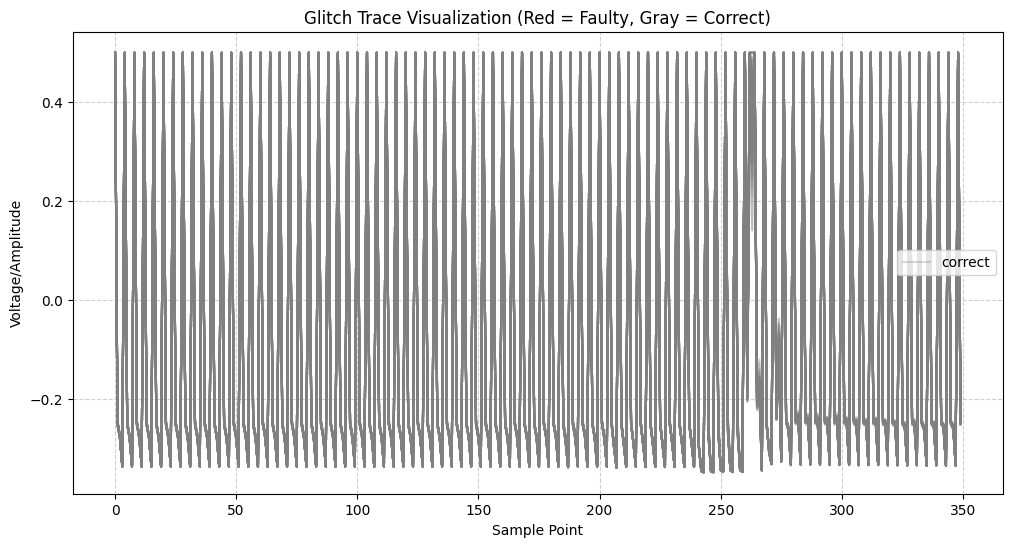

In [36]:
import matplotlib.pyplot as plt

def plot_glitch_traces(traces, labels, num_to_plot=50):
    plt.figure(figsize=(12, 6))
    
    # Track if we've added to legend to avoid duplicate labels
    added_labels = set()
    
    # Plot a subset to keep the graph readable
    for i in range(min(len(traces), num_to_plot)):
        label = labels[i]
        color = 'gray' # Default for correct
        alpha = 0.3
        
        if label == "faulty":
            color = 'red'
            alpha = 0.8
        elif label == "no_trigger":
            color = 'orange'
            alpha = 0.5
            
        line_label = label if label not in added_labels else None
        plt.plot(traces[i], color=color, alpha=alpha, label=line_label)
        if line_label:
            added_labels.add(line_label)

    plt.title("Glitch Trace Visualization (Red = Faulty, Gray = Correct)")
    plt.xlabel("Sample Point")
    plt.ylabel("Voltage/Amplitude")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Call the function
plot_glitch_traces(traces, labels)